In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import null_space

In [2]:
k0 = 2 * np.pi / 1.55
nc=1.475
n1=1.48
print(str(k0*nc) + ' < beta < ' + str(k0*n1))

5.979160211670897 < beta < 5.9994285513714765


# Сетка

In [6]:
def Grid(start, end, step):
    size = np.int32(np.round((end - start) / step))
    #grid = np.linspace(start, end, size)
    grid = np.array([start + step*i for i in range(1, size)])
    return grid

In [96]:
Grid(0,10,0.25)

array([0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75,
       3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25, 5.5 ,
       5.75, 6.  , 6.25, 6.5 , 6.75, 7.  , 7.25, 7.5 , 7.75, 8.  , 8.25,
       8.5 , 8.75, 9.  , 9.25, 9.5 , 9.75])

In [10]:
def n_fun(p, a=4, n1=1.48, nc=1.475):
    if (p <= a):
        return n1
    else:
        return nc

# Матрица с коэфицентами

In [13]:
def matrix_A(grid, h, lm=1.55):
    k = 2 * np.pi / lm 
    temp_size = np.size(grid)
    A = np.zeros((temp_size + 2,temp_size + 2))
    
    A[0][0] = -1
    A[0][1] = 1
    
    A[-1][-1] = 1
    
    for i in range(1,temp_size + 1):
        A[i][i-1] = (1 / (h**2)) - (1 / (2*h*grid[i-1]))
        A[i][i] = (-2 / (h**2)) + (n_fun(grid[i-1])**2 * k**2)
        A[i][i+1] = (1 / (h**2)) + (1 / (2*h*grid[i-1]))
    return A

In [75]:
A = matrix_A(Grid(0,13,0.25),0.25)
d = pd.DataFrame(A)
#d

In [ ]:
AA = matrix_A(Grid(0,1000,0.25),0.25)
d = pd.DataFrame(AA)
AAeug, AAv = np.linalg.eig(AA)
np.sort(np.real(AAeug))

In [17]:
pd.DataFrame(A).head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,-1.0,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8.0,3.993143,24.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,12.000000,3.993143,20.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,13.333333,3.993143,18.666667,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,14.000000,3.993143,18.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# QR разложение, метод Хаусхолдера
(см. 3ю лекцию)

In [19]:
def vector_Householder(a):
    if np.all(a == 0):
        return a
    e1 = np.zeros_like(a)
    e1[0] = 1
    sign = np.sign(a[0]) if a[0] != 0 else 1
    v = a + sign * np.linalg.norm(a) * e1
    
    norm_v = np.linalg.norm(v)
    if norm_v == 0:
        return v
        
    u = v / norm_v
    
    return u

def matrix_H(u):
    I = np.eye(u.shape[0])
    return I - 2*u*(u.reshape(-1, 1))

def matrix_P(H, n, size):
    P = np.eye(size)
    P[n:, n:] = H
    return P

def QR(A):
    A_size = min(A.shape[0], A.shape[1])
    temp_A = np.copy(A)

    Q = np.eye(A.shape[0])
    
    for n in range(A_size):
        temp_a = temp_A[n:, n]
        u = vector_Householder(temp_a)
        temp_H = matrix_H(u)
        temp_P = matrix_P(temp_H, n, A.shape[0])
        
        temp_A = np.dot(temp_P, temp_A)
        temp_A[n+1:, n] = 0 
        Q = np.dot(Q, temp_P)

    
    R = temp_A
    
    return Q, R

# Проверка
Совпадает с точностью до знаков, что допустимо

In [21]:
test_matrix = np.array([[2, -9, 5],
                        [1.2, -5.3999, 6],
                        [1, -1, -7.5]])
q,r = QR(test_matrix)
npq, npr = np.linalg.qr(test_matrix)
print('my: ')
print(q @ r)
print('numpy: ')
print(npq @ npr)

my: 
[[ 2.     -9.      5.    ]
 [ 1.2    -5.3999  6.    ]
 [ 1.     -1.     -7.5   ]]
numpy: 
[[ 2.     -9.      5.    ]
 [ 1.2    -5.3999  6.    ]
 [ 1.     -1.     -7.5   ]]


In [23]:
print('Q my: ')
print(q)
print('Q numpy: ')
print(npq)

Q my: 
[[-7.88110406e-01 -3.37913264e-01  5.14486748e-01]
 [-4.72866244e-01 -2.02716871e-01 -8.57498330e-01]
 [-3.94055203e-01  9.19086773e-01  2.44999523e-05]]
Q numpy: 
[[-7.88110406e-01 -3.37913264e-01 -5.14486748e-01]
 [-4.72866244e-01 -2.02716871e-01  8.57498330e-01]
 [-3.94055203e-01  9.19086773e-01 -2.44999523e-05]]


In [25]:
print('R my: ')
print(r)
print('R numpy: ')
print(npr)
print('difference in modulus')
print(abs(npr) - abs(r))

R my: 
[[-2.53771551 10.04047929 -3.82233547]
 [ 0.          3.21678343 -9.79901834]
 [ 0.          0.         -2.57273999]]
R numpy: 
[[-2.53771551 10.04047929 -3.82233547]
 [ 0.          3.21678343 -9.79901834]
 [ 0.          0.          2.57273999]]
difference in modulus
[[4.44089210e-16 7.10542736e-15 8.88178420e-16]
 [0.00000000e+00 1.33226763e-15 1.77635684e-15]
 [0.00000000e+00 0.00000000e+00 1.11022302e-14]]


# Тест на матрице полученной по сетке

In [28]:
pd.DataFrame(A).head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,-1.0,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8.0,3.993143,24.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,12.000000,3.993143,20.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,13.333333,3.993143,18.666667,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,14.000000,3.993143,18.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
Q,R = QR(A)

In [32]:
df_Q = pd.DataFrame(Q)
df_R = pd.DataFrame(R)

In [34]:
df_R.head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,8.062258,3.838273,23.814669,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,-12.091851,-4.329027,-19.848078,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,13.558910,3.479770,18.356114,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,-14.348874,-4.639222,-17.562354,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,14.604121,3.280045,17.354006,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
npQ, npR = np.linalg.qr(A)
pd.DataFrame(npR).head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,8.062258,3.838273,23.814669,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,-12.091851,-4.329027,-19.848078,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,13.558910,3.479770,18.356114,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,-14.348874,-4.639222,-17.562354,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,14.604121,3.280045,17.354006,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
np.max(np.abs(npR) - np.abs(R))

1.509903313490213e-14

In [40]:
checkQR_df = pd.DataFrame(np.dot(Q,R))
#checkQR_df

# QR алгоритм

In [43]:
def lower_triangular_norm(T):
    n = T.shape[0]
    norm = 0
    for i in range(1, n):
        for j in range(0, i):
            norm += T[i, j] ** 2
    return np.sqrt(norm)

In [45]:
def QR_algorithm(A, e=1e-3, max_iter=1e+5):
    k = 0
    temp0 = np.copy(A)
    while True:
        Q,R = QR(temp0)
        temp1 = R @ Q

        if k >= max_iter:
            temp0 = temp1.copy()
            break
        #print(lower_triangular_norm(temp1))
        if lower_triangular_norm(temp1) < e:
            print(f"Алгоритм сошелся на итерации {k}")
            print(lower_triangular_norm(temp1 - np.diag(np.diag(temp1))))
            temp0 = temp1.copy()
            break
        
        k+=1
        temp0 = temp1.copy()
        
    return temp0
    

In [678]:
check = pd.DataFrame(QR_algorithm(A))
np.diag(check)

94.7872347761124
96.36763162544267
92.56528358929211
92.48604849010127
89.39659933541712
89.67460137033152
87.1559375145099
88.1919603238423
85.7936781756702
87.30213968305314
84.80152140373697
86.4923406591462
83.85236404986632
85.64626350689994
82.92115147374363
84.78484553120936
81.85933021750759
83.46598574479634
80.22399369106759
81.33148668540821
78.09017924993942
79.00131141711067
76.09625969737527
77.09398803208502
74.49493977261969
75.53597618313026
73.06631027234474
74.01265262960294
71.56332745101528
72.30147063233784
69.77548972001419
70.20441966867244
67.70205586182236
68.06587943817622
65.86758932729664
66.40054255243207
64.23166469373498
64.42723903167045
61.735998866810704
61.140479677830065
58.16804116858922
57.23561819756533
54.69219095462648
54.09652578233055
52.263963936310745
52.19225954255631
50.96752233934339
51.417301575466
50.71048892680173
51.591721261212435
51.12702080322391
52.19550271701285
51.97950522693727
53.57187336465272
54.102398354886134
56.704901808

array([ 35.81375479,  35.48946743,  35.02009335,  34.37217612,
        33.49827106,  32.46604078,  31.24244483,  29.8461045 ,
        28.30016459, -28.10849394, -27.77306365, -27.34173386,
       -26.65647485,  26.58531893, -25.81005724, -24.76614147,
        24.74408792, -23.54046445,  22.76404852, -22.15770824,
        20.6675714 , -20.59484542, -18.89743628,  18.47333693,
       -17.04701514,  16.17760812, -15.07150823,  13.8182632 ,
       -12.98351554,  11.38913769, -10.78337968,   8.9195906 ,
        -8.50940586,   6.42615195,  -6.15836508,   3.92124757,
        -3.79168633,  -1.68653048,   1.47239125,  -0.58095148,
         1.        ])

In [47]:
def QR_np(A, max_iterations = 1000000, epsilon = 1e-3 ):
    T = np.copy(A)
    Q_ = np.eye(A.shape[0])
    for k in range(max_iterations):
        Q, R = np.linalg.qr(T)  
        
        T_new = R @ Q      
        Q_ = Q_ @ Q
        #if k % 10 == 0:
            #print(lower_triangular_norm(T_new))
        if lower_triangular_norm(T_new) < epsilon:
            print(f"Алгоритм сошелся на итерации {k}")
            break
    
        T = T_new
    return T, Q_

In [686]:
T, eigenvectors  = QR_np(A)

Алгоритм сошелся на итерации 6184


In [690]:
np.max((np.diag(T) - np.diag(check)))

3.309145772689703e-05

In [56]:
np.diag(T)

array([ 35.81378921,  35.48994229,  35.02118329,  34.3743189 ,
        33.50173236,  32.47102464,  31.24952412,  29.85537113,
        28.31222621, -28.10881573, -27.77381049, -27.34335859,
       -26.65955671,  26.60057071, -25.81473201, -24.77332087,
        24.76293446, -23.550249  ,  22.78740948, -22.17109412,
        20.69586994, -20.6124825 , -18.92017889,  18.5079693 ,
       -17.07662269,  16.21985657, -15.10923039,  13.87014208,
       -13.03287687,  11.45445572, -10.848617  ,   9.00346903,
        -8.59919074,   6.54094265,  -6.29234649,   4.09433756,
        -4.01674103,  -2.04537366,   1.79706332,  -0.72314853,
         0.19610769])

In [102]:
np.diag(check)

array([ 35.81377434,  35.48995559,  35.02118485,  34.37431891,
        33.50173236,  32.47102465,  31.24952411,  29.85537113,
       -28.10880827,  28.3036526 , -27.76524421, -27.34335872,
       -26.65954357,  26.60055758, -25.814732  , -24.7698894 ,
        24.75950298, -23.550249  ,  22.78740947, -22.17109412,
        19.03953836, -18.95615095, -18.92017885,  18.50796929,
       -17.07662268,  16.21985656, -15.10923038,  13.87014208,
       -13.03287687,  11.45445572, -10.848617  ,   9.00346903,
        -8.59919074,   6.54094265,  -6.2923465 ,   4.09433757,
        -4.01674102,  -2.04537366,   1.79706331,  -0.72314852,
         0.19610767])

In [709]:
test_matrix

array([[ 2.    , -9.    ,  5.    ],
       [ 1.2   , -5.3999,  6.    ],
       [ 1.    , -1.    , -7.5   ]])

In [722]:
#max_iterations
qr_np, ttt = QR_np(test_matrix,max_iterations=100)
print(np.diag(qr_np))
qr_np, ttt = QR_np(test_matrix,max_iterations=1000)
print(np.diag(qr_np))
qr_np, ttt = QR_np(test_matrix,max_iterations=10000)
print(np.diag(qr_np))
qr_np, ttt = QR_np(test_matrix,max_iterations=100000)
print(np.diag(qr_np))

[-7.87279398 -2.07134373 -0.95576229]
[-7.87279398 -1.2180699  -1.80903612]
[-7.87279398 -1.59227686 -1.43482916]
[-7.87279398 -1.29909498 -1.72801104]


In [726]:
qr_np, ttt = QR_np(test_matrix,max_iterations=1000000)
print(np.diag(qr_np))

[-7.87279398 -3.28854401  0.26143798]


In [736]:
qr_my = QR_algorithm(test_matrix,max_iter=100)
print(qr_my)
qr_my = QR_algorithm(test_matrix,max_iter=1000)
print(qr_my)

[[-7.87279398e+00 -1.05097552e+01  3.81882520e+00]
 [ 9.88480809e-68 -1.74253877e+00 -6.56801563e+00]
 [ 2.62896717e-69  6.53560692e-02 -1.28456726e+00]]
[[ -7.87279398 -10.93643542   2.33082825]
 [  0.          -0.84438658  -6.50663822]
 [  0.           0.12673348  -2.18271944]]


In [728]:
qr_np

array([[-7.87279398,  9.22064339, -6.3259873 ],
       [ 0.        , -3.28854401, -6.05036227],
       [ 0.        ,  0.58300943,  0.26143798]])

In [786]:
a_test[0].size

3

In [788]:
btest = np.zeros((10,10))

btest[0][0] = 1
btest[-1][-1] = 1
for i in range(1,btest[0].size - 1):
    btest[i][i-1] = i
    btest[i][i] = 2*i
    btest[i][i+1] = 1

In [790]:
btest

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2.,  4.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  3.,  6.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  4.,  8.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5., 10.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  6., 12.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  7., 14.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  8., 16.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [792]:
bmy = pd.DataFrame(QR_algorithm(btest))
print("my: " + str(np.diag(bmy)))

Алгоритм сошелся на итерации 48
0.0008829289805305381
my: [18.46803655 14.64077301 11.83059054  9.55579093  7.5036319   5.48956698
  3.41866482  1.09429178  0.99865348  1.        ]


In [794]:
beug, bv = np.linalg.eig(btest)
print(np.real(beug))

[18.46729361 14.64018758 11.83098439  9.55652335  7.50382782  5.48957316
  3.41866483  1.09294526  1.          1.        ]


In [780]:
a_test = np.array([[4, 1, 5],
                 [0, 3, 1],
                 [0, 1, 3]])

In [782]:
amy = pd.DataFrame(QR_algorithm(a_test))
print("my: " + str(np.diag(amy)))

Алгоритм сошелся на итерации 10
0.0009765622671694127
my: [4.         3.99999952 2.00000048]


In [784]:
aeug, av = np.linalg.eig(a_test)
print(np.real(aeug))

[4. 4. 2.]


In [718]:
eug, v = np.linalg.eig(test_matrix)
my = pd.DataFrame(QR_algorithm(test_matrix))
#QR_np
qr_np, ttt = QR_np(test_matrix)
print("my: " + str(np.diag(my)))
print("all numpy: " + str(np.real(eug)))
print(np.diag(qr_np))

[-7.87279398 -0.97865282 -2.0484532 ]
[-1.51355301 -1.51355301 -7.87279398]
[-7.87279398 -3.28854401  0.26143798]


In [724]:
print("my: " + str(np.diag(my)))
print("all numpy: " + str(np.real(eug)))
print(np.diag(qr_np))

my: [-7.87279398 -0.97865282 -2.0484532 ]
all numpy: [-1.51355301 -1.51355301 -7.87279398]
[-7.87279398 -1.29909498 -1.72801104]


# Собственные значения и вектора для матрицы A через numpy

In [696]:
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Собственные значения:", np.real(eigenvalues))
print("Собственные векторы:\n", eigenvectors)

Собственные значения: [-28.10849394 -27.77306365 -27.34173386 -26.65647485 -25.81005724
 -24.76615802 -23.54046445 -22.15770824 -20.59484542 -18.89743628
 -17.04701514 -15.07150823 -12.98351554 -10.78337968  -8.50940586
  -6.15836508  -3.79168633  -1.68653048  -0.58095148   1.47239125
   3.92124757   6.42615195   8.9195906   11.38913769  13.8182632
  35.81375479  35.48946743  35.02009335  34.37217612  33.49827106
  32.46604078  31.24244483  29.8461045   28.30016459  26.58531893
  16.17760812  24.74410448  22.76404852  18.47333693  20.66757141
   1.        ]
Собственные векторы:
 [[-0.00233308 -0.00595409  0.00833486 ... -0.02941904 -0.02565678
  -0.28543681]
 [ 0.06324627  0.15940929 -0.21955454 ... -0.57288689 -0.55592002
  -0.57087361]
 [-0.0838185  -0.20900816  0.28387648 ... -0.33584004 -0.3776831
   0.1663417 ]
 ...
 [-0.03280121  0.03784376  0.05134354 ...  0.08660805 -0.09496913
  -0.04479472]
 [ 0.01626207 -0.01896169 -0.02608267 ...  0.09291346 -0.08866857
  -0.08583555]
 [ 0.

# Проверка результатов (моего) QR разложения матрицы A и результатов от numpy

Совпадают с точностью до знаков

In [704]:
np.sort(np.abs(np.real(eigenvalues))) - np.sort(np.abs(np.diag(check)))

array([ 4.66293670e-15,  0.00000000e+00, -2.66453526e-15,  5.99520433e-15,
        6.21724894e-15, -2.88657986e-14, -3.01980663e-14, -2.04281037e-14,
       -1.59872116e-14,  1.84741111e-13, -1.11910481e-13,  5.32907052e-15,
        3.73034936e-14, -2.34479103e-13,  2.48689958e-14,  7.10542736e-15,
        1.59872116e-13, -7.46069873e-14, -2.06057393e-13,  3.99774081e-09,
        3.99846201e-09, -2.13162821e-14, -2.73558953e-13, -5.25801624e-13,
        1.65585367e-05,  1.65585374e-05, -1.31450406e-13,  6.14264195e-12,
        5.79447601e-12,  6.39488462e-14, -1.63424829e-13,  1.26938460e-11,
        1.15107923e-11, -7.81597009e-14, -2.73558953e-13,  1.06581410e-13,
        5.04485342e-13,  4.12114787e-13, -1.00186526e-12,  7.46069873e-13,
        1.17950094e-12])

In [529]:
np.sort(np.real(eigenvalues))

array([-28.10849394, -27.77306365, -27.34173386, -26.65647485,
       -25.81005724, -24.76615802, -23.54046445, -22.15770824,
       -20.59484542, -18.89743628, -17.04701514, -15.07150823,
       -12.98351554, -10.78337968,  -8.50940586,  -6.15836508,
        -3.79168633,  -1.68653048,  -0.58095148,   1.        ,
         1.47239125,   3.92124757,   6.42615195,   8.9195906 ,
        11.38913769,  13.8182632 ,  16.17760812,  18.47333693,
        20.66757141,  22.76404852,  24.74410448,  26.58531893,
        28.30016459,  29.8461045 ,  31.24244483,  32.46604078,
        33.49827106,  34.37217612,  35.02009335,  35.48946743,
        35.81375479])

In [796]:
H = np.array([2**i for i in range(2,10)])
A_h = []
r_edge = 10
for h in H:
    A_h.append(matrix_A(Grid(0,r_edge,1/h),1/h))

In [798]:
for a in A_h:
    eigenvalues, eigenvectors = np.linalg.eig(a)

    print("Собственные значения:", np.max(np.sort(np.real(eigenvalues))))
    

Собственные значения: 35.8137547916916
Собственные значения: 35.81578675453125
Собственные значения: 35.81825236189798
Собственные значения: 35.82066277196892
Собственные значения: 35.82285010661107
Собственные значения: 35.82477665705219
Собственные значения: 35.82645511496871
Собственные значения: 35.827914801633085


In [832]:
np.sqrt(beta)

array([5.98445944, 5.98462921, 5.9848352 , 5.98503657, 5.9852193 ,
       5.98538024, 5.98552045, 5.98564239])

In [799]:
eigenvalues_ = []
eigenvectors_ = []
for a in A_h:
    eigenvalues, eigenvectors = np.linalg.eig(a)
    eigenvalues_.append(eigenvalues)
    eigenvectors_.append(eigenvectors)

In [800]:
beta = []
for ev in eigenvalues_:
    beta.append(np.max(np.real(ev)))
beta

[35.8137547916916,
 35.81578675453125,
 35.81825236189798,
 35.82066277196892,
 35.82285010661107,
 35.82477665705219,
 35.82645511496871,
 35.827914801633085]

In [824]:
np.sqrt(beta)

array([5.98445944, 5.98462921, 5.9848352 , 5.98503657, 5.9852193 ,
       5.98538024, 5.98552045, 5.98564239])

In [822]:
for i in range(2, len(beta)):
    pp = np.log2( (np.sqrt(beta[i-2]) - np.sqrt(beta[i-1])) 
                 / (np.sqrt(beta[i-1]) - np.sqrt(beta[i])))
    print(pp)

-0.2790237675406498
0.03271357100915543
0.14015094361541092
0.18319541690173288
0.19891988834140453
0.20150924364831388


In [830]:
for i in range(1, len(beta)):
    pp = beta[i-1] / beta[i]
    print(pp)

0.9999432662793762
0.9999311633816799
0.9999327089482882
0.9999389402396615
0.9999462229601719
0.9999531503211486
0.9999592583974687


In [826]:
k0 = 2 * np.pi / 1.55
nc=1.475
n1=1.48
print(str((k0*nc)**2) + ' < beta^2 < ' + str((k0*n1)**2))
print(str(k0*nc) + ' < beta < ' + str(k0*n1))

35.75035683682837 < beta^2 < 35.99314294301125
5.979160211670897 < beta < 5.9994285513714765


In [836]:
np.sqrt(beta) < 5.9994285513714765

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [838]:
5.979160211670897 < np.sqrt(beta)

array([ True,  True,  True,  True,  True,  True,  True,  True])

# Построить графики 
Собственные вектора соответсвующие собсвенным занчениям

In [77]:
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Собственные значения:", np.real(eigenvalues))
print("Собственные векторы:\n", eigenvectors)

Собственные значения: [-28.17408416 -27.95614594 -27.67328167 -27.30318804 -26.78110686
 -26.15766753 -25.43471104 -24.5868223  -23.63888901 -22.5996036
 -21.45218531 -20.21216962 -18.89305952 -17.48353822 -15.99344802
 -14.43937319 -12.81482733 -11.12577068  -9.39095313  -7.60945486
  -5.78763114  -3.95753473  -2.20042166  -1.03932556   0.1721797
   1.98079786   3.88211795   5.80899157   7.73471291   9.64379395
  11.53886485  13.4079813   15.23596879  35.81800415  35.61683398
  35.32824515  34.94317848  34.4447021   33.8126762   33.07659962
  32.24427647  31.29534454  30.24327239  29.10508511  27.8682971
  26.53747257  25.13208414  23.64721657  17.02663426  22.08253489
  18.77288239  20.45722051   1.        ]
Собственные векторы:
 [[ 1.47961491e-03  3.85321481e-03 -6.58748748e-03 ...  2.80955381e-02
   2.53015604e-02 -2.78133766e-01]
 [-4.02071801e-02 -1.03867821e-01  1.75709909e-01 ...  5.55529771e-01
   5.42901161e-01 -5.56267532e-01]
 [ 5.33965239e-02  1.36986554e-01 -2.29641862e-0

In [79]:
temp_val = np.real(eigenvalues)[(np.real(eigenvalues) > 35.75035683682837) & (np.real(eigenvalues) < 35.99314294301125)][0]

In [81]:
temp_val

35.8180041541676

In [83]:
[(np.real(eigenvalues) > 35.75035683682837) & (np.real(eigenvalues) < 35.99314294301125)]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False])]

In [85]:
temp = eigenvectors[:,(np.real(eigenvalues) > 35.75035683682837) & (np.real(eigenvalues) < 35.99314294301125)].T[0]

In [87]:
temp

array([-0.00402771, -0.14829219, -0.1952982 , -0.22179159, -0.23863449,
       -0.24941263, -0.25574919, -0.25852676, -0.25829276, -0.25542529,
       -0.25021089, -0.24288466, -0.23365243, -0.22270349, -0.21021811,
       -0.19637206, -0.18133912, -0.16529244, -0.15084161, -0.13779241,
       -0.12598004, -0.11526354, -0.10552147, -0.09664861, -0.08855325,
       -0.08115508, -0.07438341, -0.06817584, -0.06247701, -0.05723765,
       -0.05241379, -0.04796606, -0.0438591 , -0.0400611 , -0.03654332,
       -0.03327977, -0.03024687, -0.0274232 , -0.02478922, -0.0223271 ,
       -0.02002052, -0.01785449, -0.01581524, -0.01389004, -0.01206716,
       -0.01033568, -0.00868548, -0.0071071 , -0.00559167, -0.00413089,
       -0.00271691, -0.0013423 ,  0.        ])

In [90]:
import matplotlib.pyplot as plt

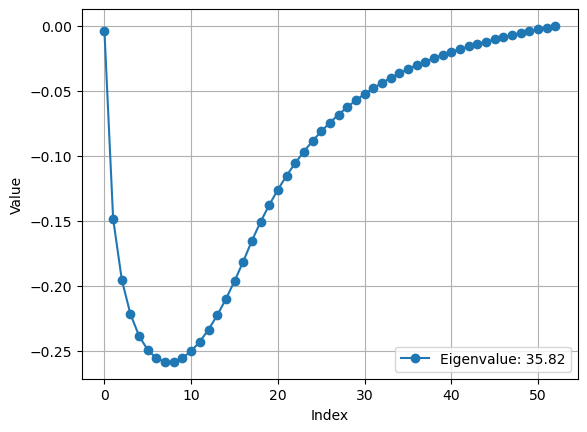

In [92]:
plt.figure()
plt.plot(temp, marker='o', label=f'Eigenvalue: {temp_val:.2f}')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid()

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9392\3217883734.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


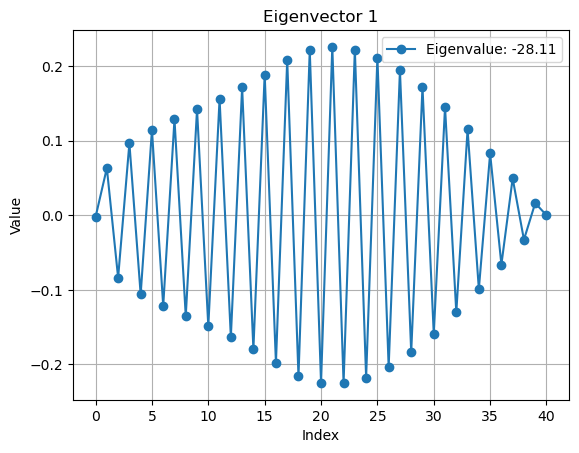

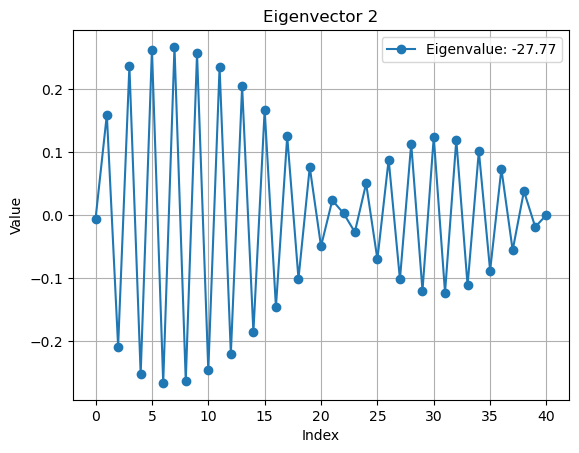

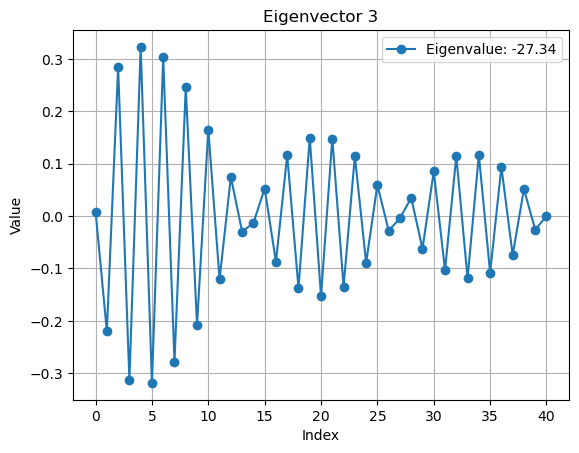

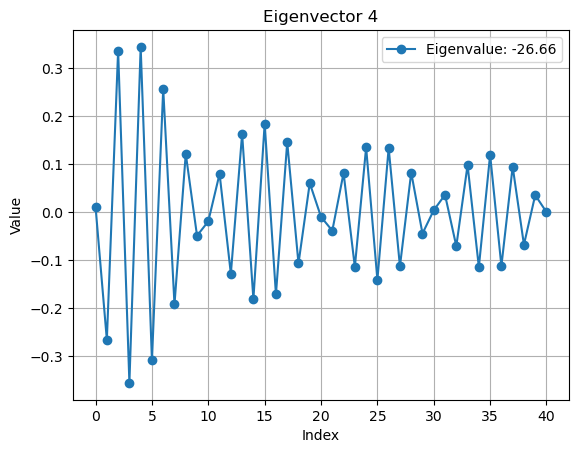

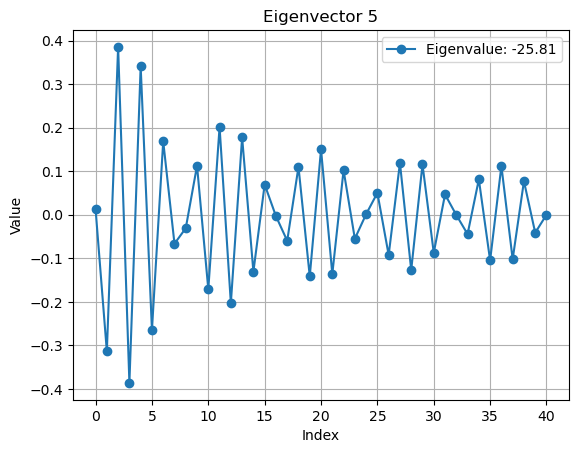

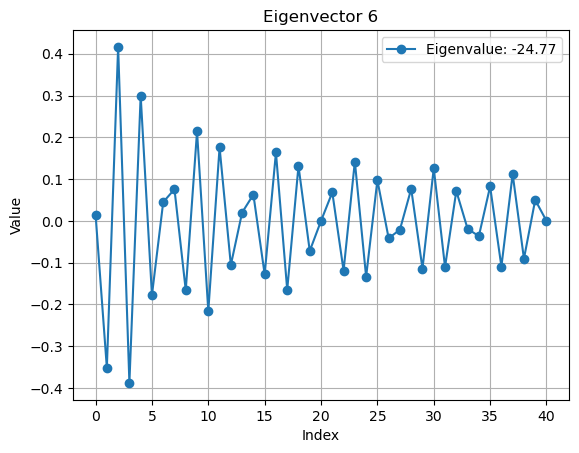

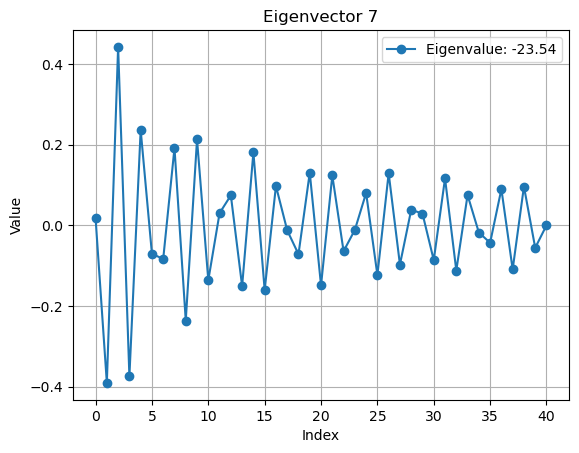

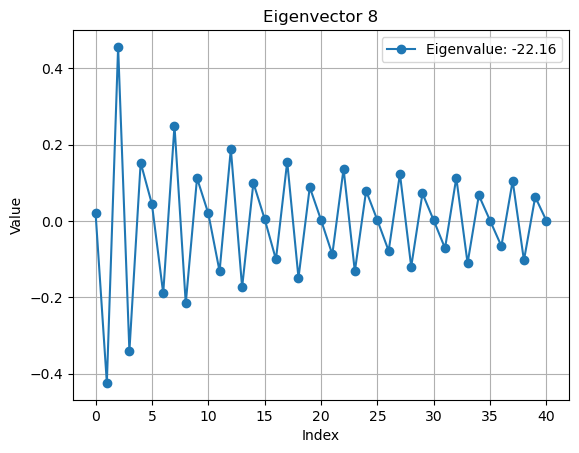

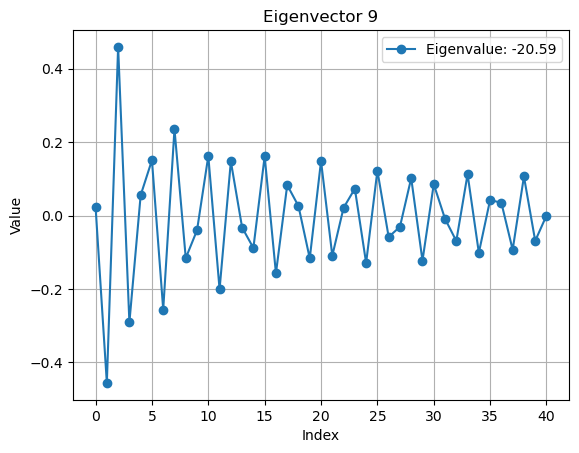

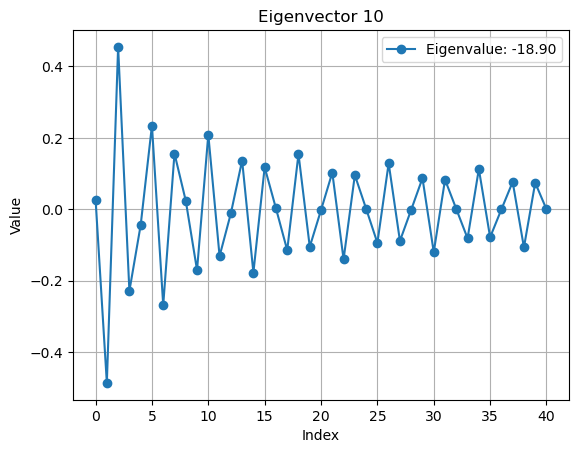

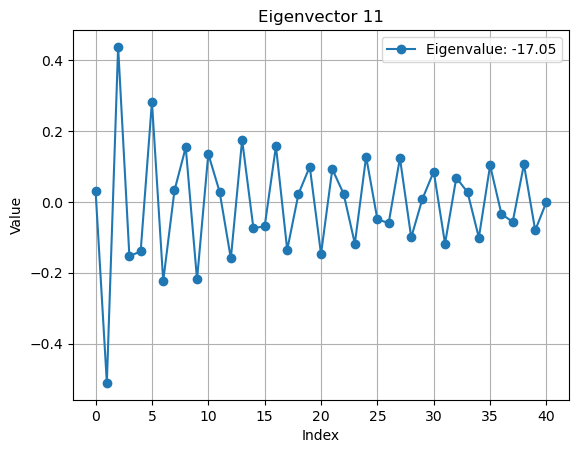

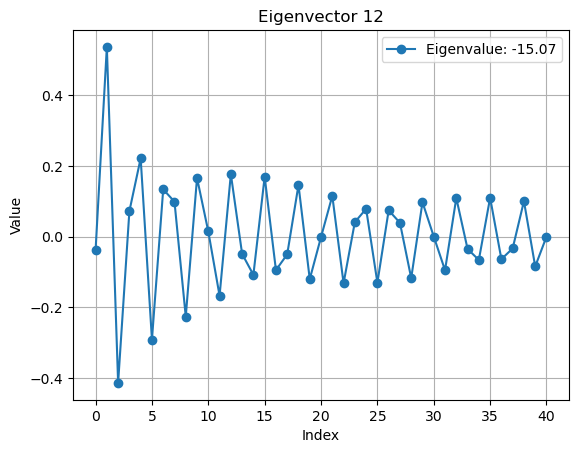

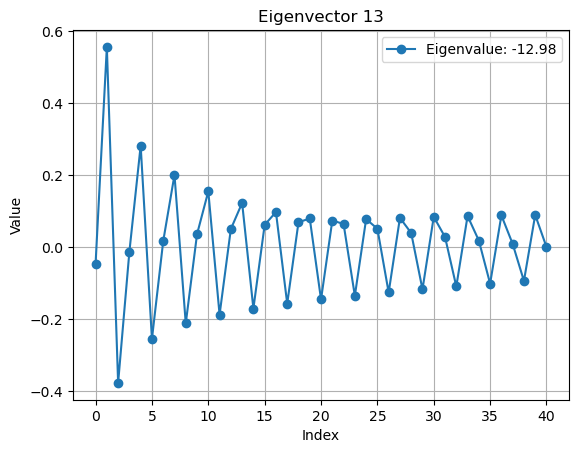

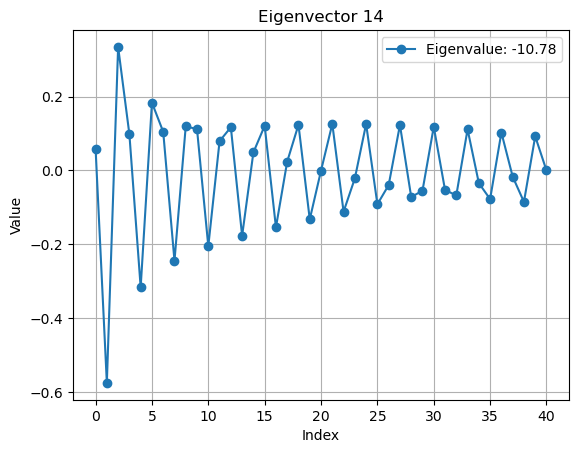

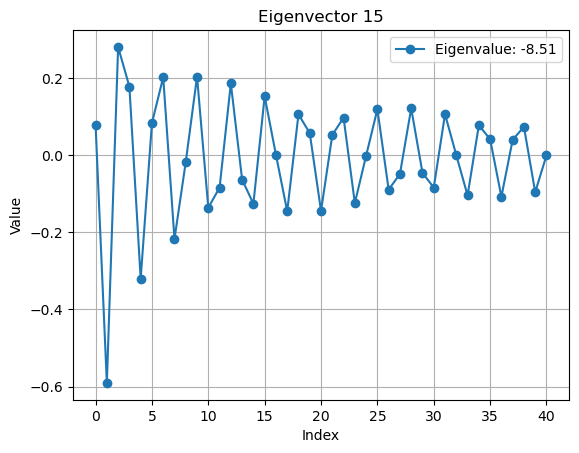

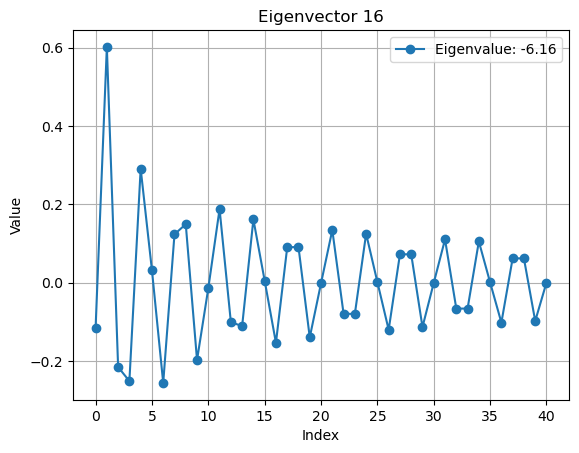

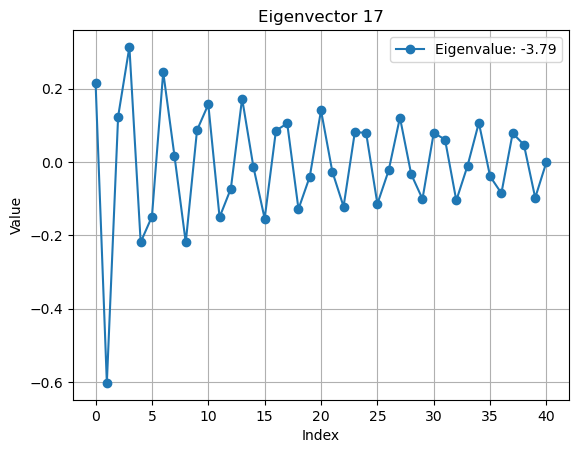

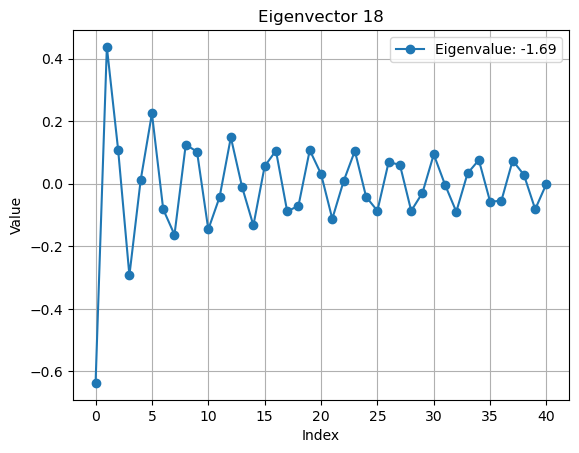

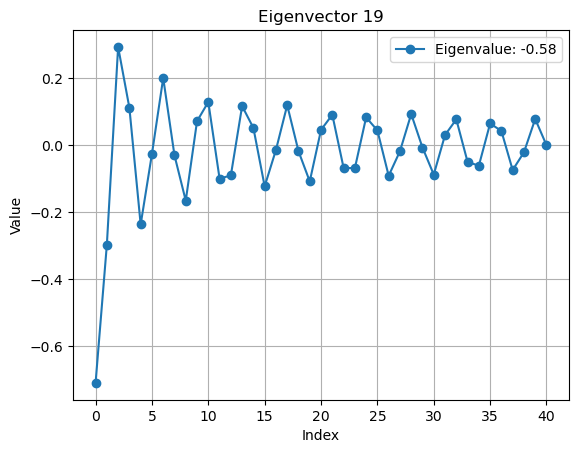

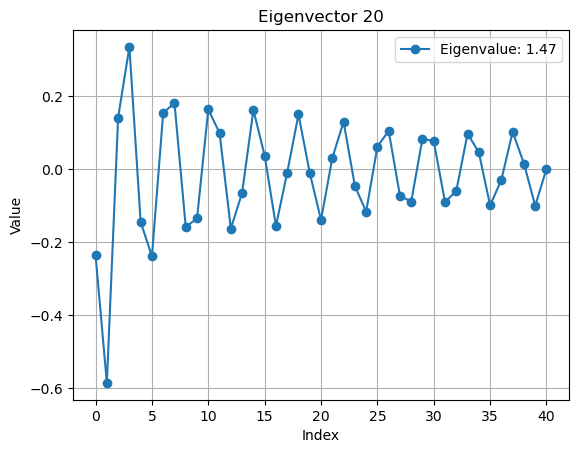

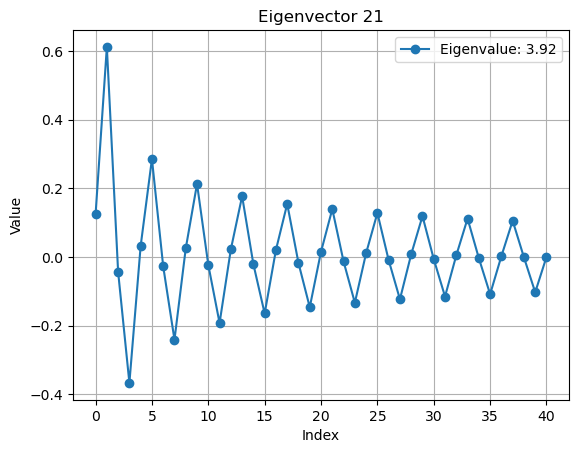

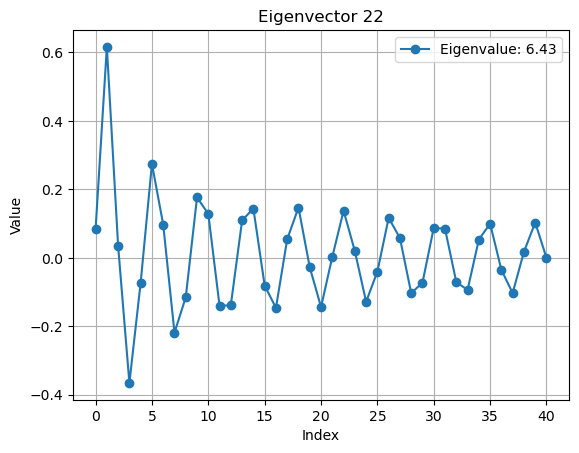

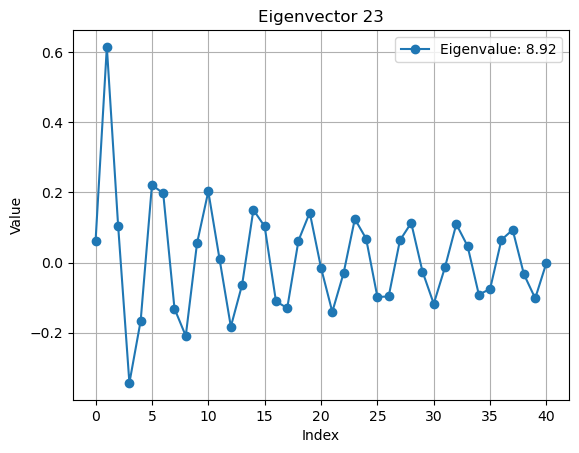

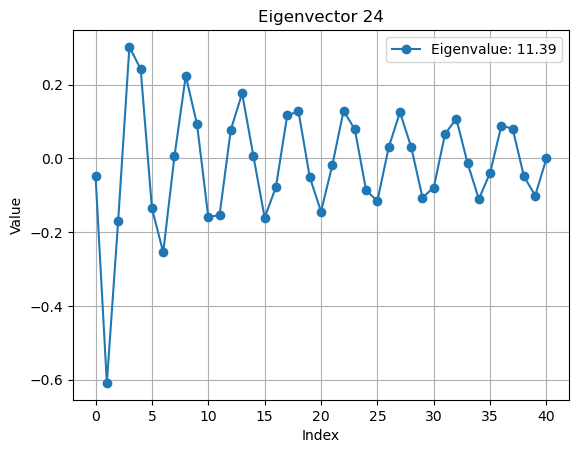

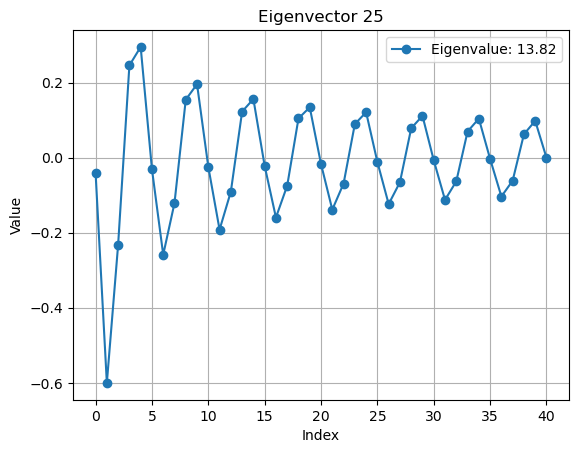

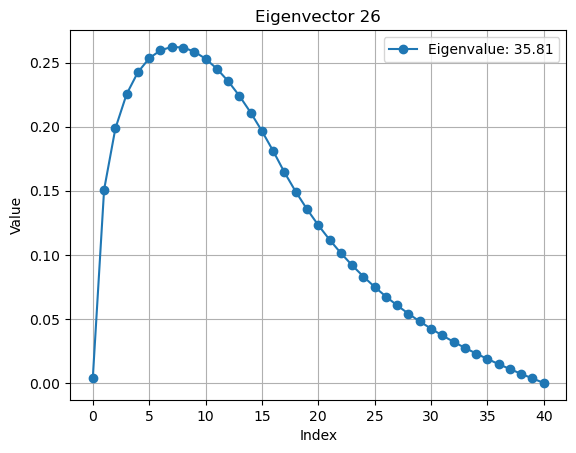

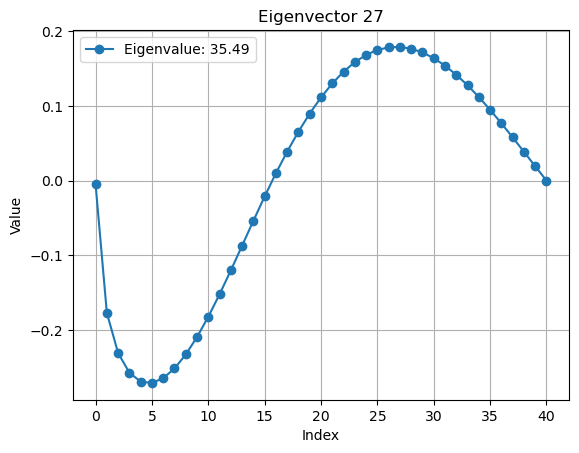

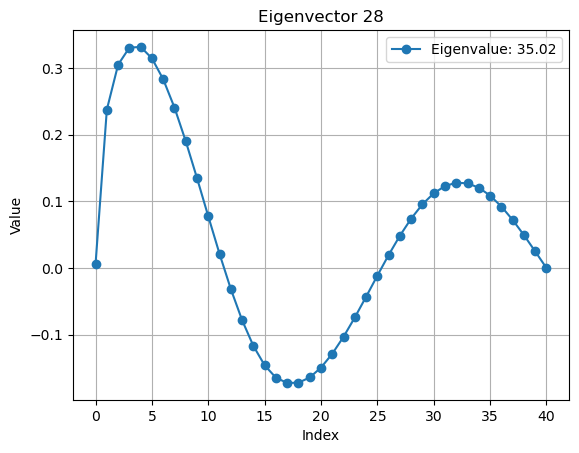

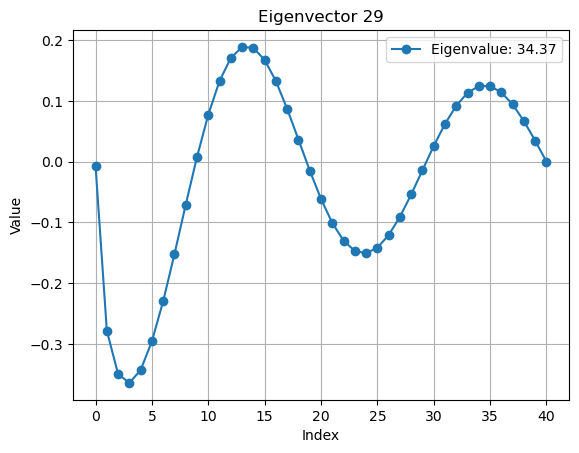

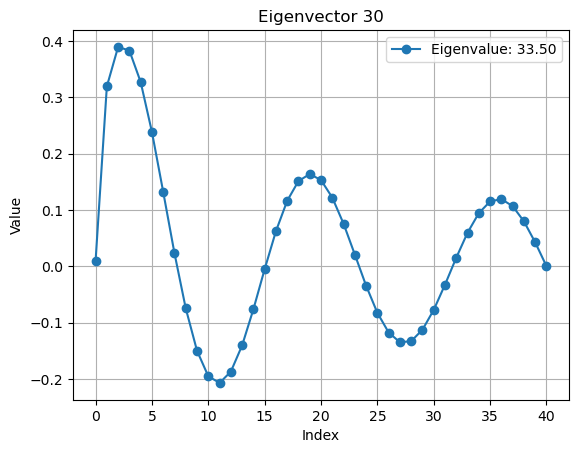

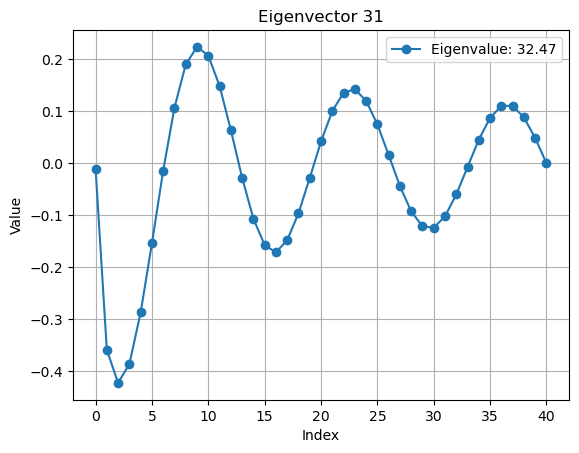

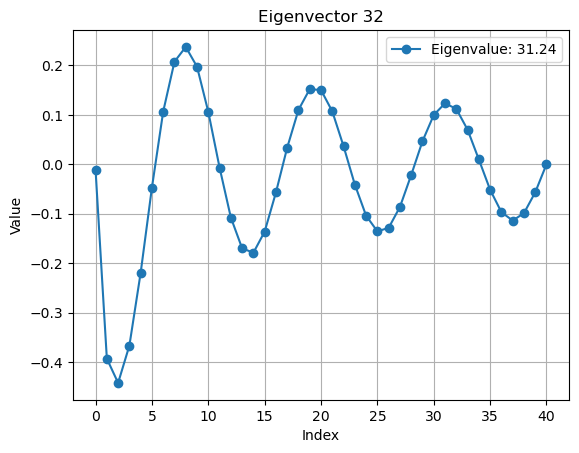

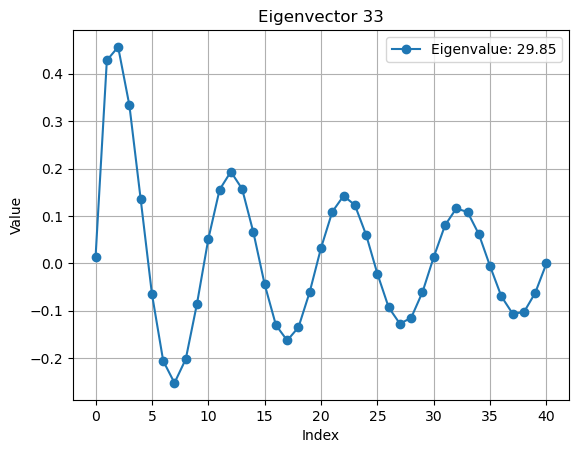

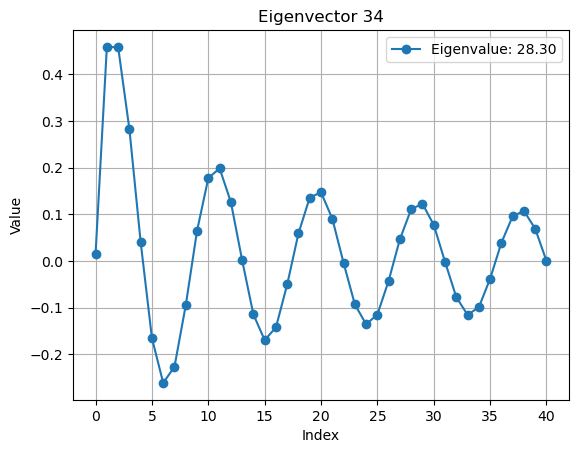

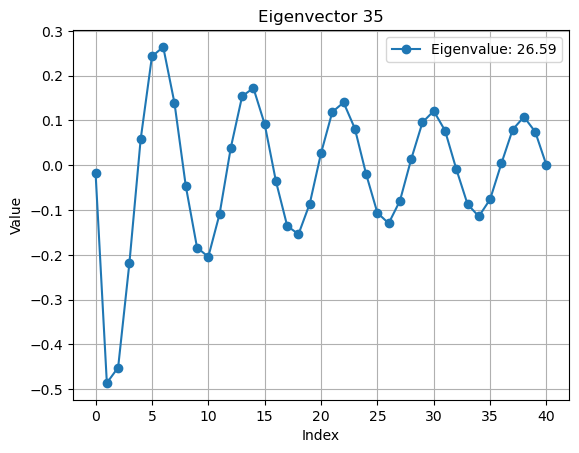

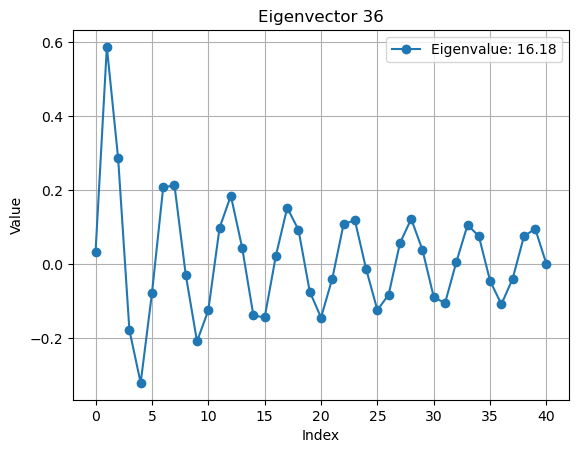

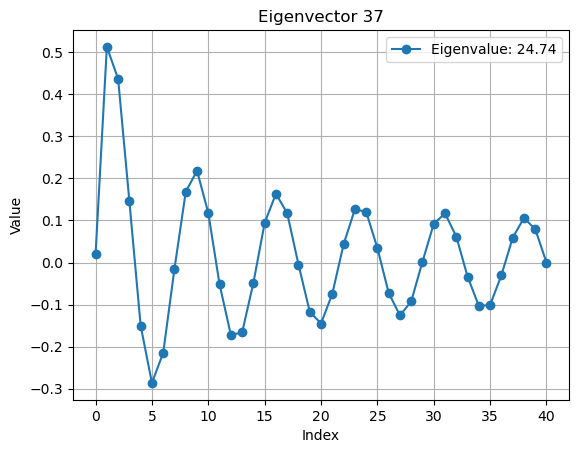

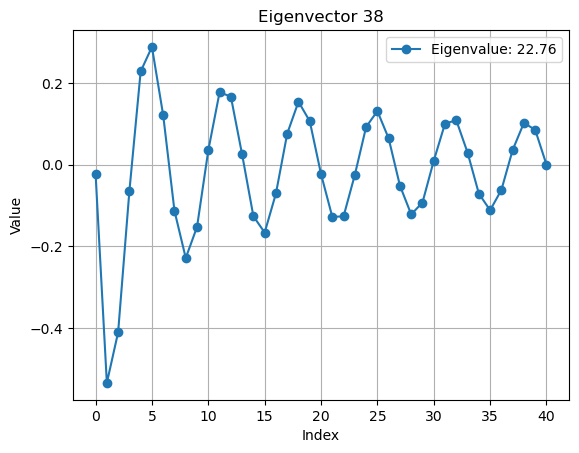

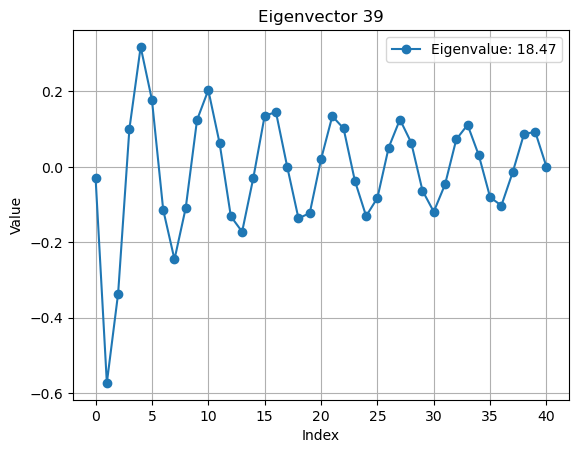

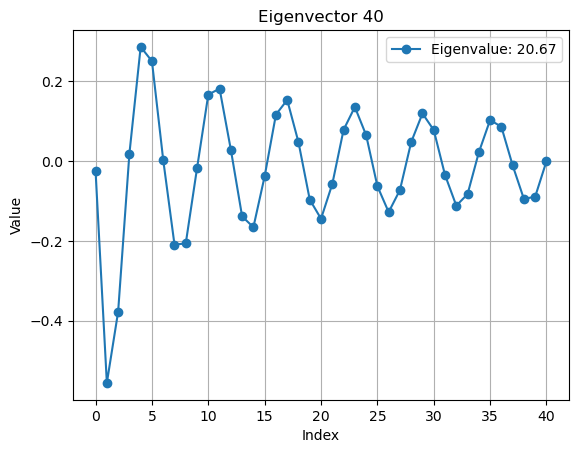

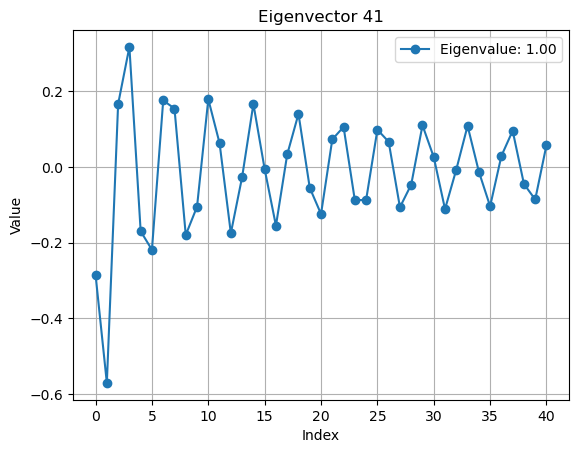

In [84]:
for i in range(len(eigenvalues)):
    plt.figure()
    plt.plot(eigenvectors[:, i], marker='o', label=f'Eigenvalue: {eigenvalues[i]:.2f}')
    plt.title(f'Eigenvector {i+1}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()

plt.show()